In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
df =pd.read_csv("train.csv")
df=df[['Id','Neighborhood','HouseStyle','OverallQual','OverallCond','YearBuilt','TotalBsmtSF','1stFlrSF','2ndFlrSF','GrLivArea','MoSold','YrSold','SalePrice']]

In [32]:
df

,Id,Neighborhood,HouseStyle,OverallQual,OverallCond,YearBuilt,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,MoSold,YrSold,SalePrice,Price per Sqft
0,1,CollgCr,2Story,7,5,2003,856,856,854,1710,2,2008,208500,121.929825
1,2,Veenker,1Story,6,8,1976,1262,1262,0,1262,5,2007,181500,143.819334
2,3,CollgCr,2Story,7,5,2001,920,920,866,1786,9,2008,223500,125.139978
3,4,Crawfor,2Story,7,5,1915,756,961,756,1717,2,2006,140000,81.537566
4,5,NoRidge,2Story,8,5,2000,1145,1145,1053,2198,12,2008,250000,113.739763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,Gilbert,2Story,6,5,1999,953,953,694,1647,8,2007,175000,106.253795
1456,1457,NWAmes,1Story,6,6,1978,1542,2073,0,2073,2,2010,210000,101.302460
1457,1458,Crawfor,2Story,7,9,1941,1152,1188,1152,2340,5,2010,266500,113.888889
1458,1459,NAmes,1Story,5,6,1950,1078,1078,0,1078,4,2010,142125,131.841373


## 1. Market Trends (High Priority)

#### How have house prices evolved over time?

In [42]:
house_count=df['YrSold'].value_counts().sort_index()
house_count

YrSold
2006    314
2007    329
2008    304
2009    338
2010    175
Name: count, dtype: int64

In [36]:
price_overtime=df.groupby('YrSold')['SalePrice'].mean()

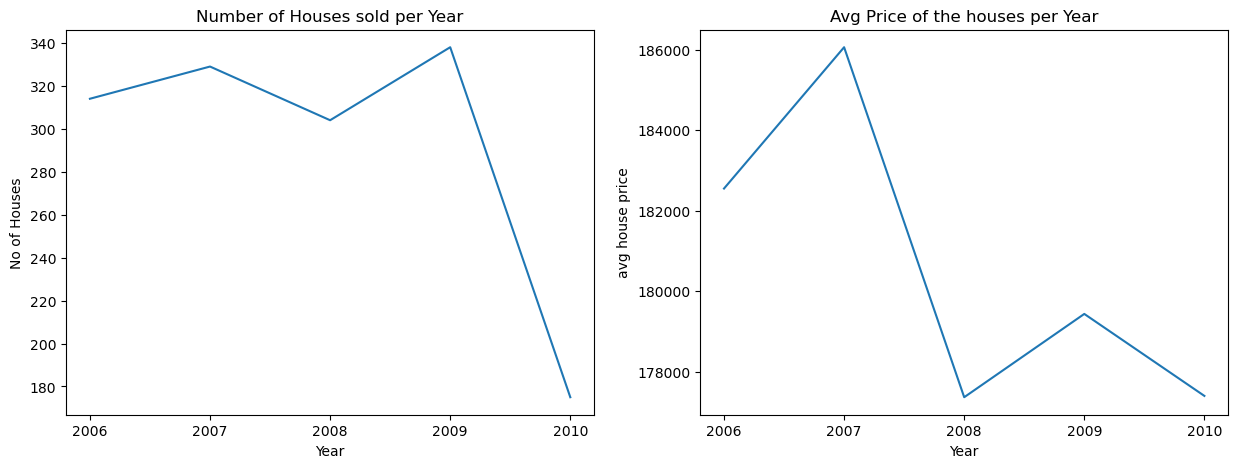

In [45]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(15,5))

ax1.plot(house_count.index,house_count.values)
ax1.set_xticks(house_count.index)
ax1.set_ylabel('No of Houses')
ax1.set_xlabel('Year')
ax1.set_title('Number of Houses sold per Year')

ax2.plot(price_overtime.index,price_overtime.values)
ax2.set_xticks(price_overtime.index)
ax2.set_ylabel('avg house price')
ax2.set_xlabel('Year')
ax2.set_title('Avg Price of the houses per Year')

plt.show()

### The housing market showed strong growth from 2006 to 2007, with both average prices and number of houses sold increasing.

### However, in 2008, both metrics dropped significantly, likely indicating the impact of the financial crisis.

### In 2009, the market showed signs of recovery, with an increase in both sales volume and average prices.

### Interestingly, while 2009 had more houses sold than 2006–2007, the average price remained lower, suggesting weaker market value.

### In 2010, both the number of houses sold and average prices declined again, though this may be influenced by lower data availability.

#####

#### Are newer houses (post-2000) priced significantly higher than older ones?

In [15]:
df['new_or_old']=df['YearBuilt'].apply(lambda x : 'new' if x >= 2000 else 'old' )
df

,Id,Neighborhood,HouseStyle,OverallQual,OverallCond,YearBuilt,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,MoSold,YrSold,SalePrice,new_or_old
0,1,CollgCr,2Story,7,5,2003,856,856,854,1710,2,2008,208500,new
1,2,Veenker,1Story,6,8,1976,1262,1262,0,1262,5,2007,181500,old
2,3,CollgCr,2Story,7,5,2001,920,920,866,1786,9,2008,223500,new
3,4,Crawfor,2Story,7,5,1915,756,961,756,1717,2,2006,140000,old
4,5,NoRidge,2Story,8,5,2000,1145,1145,1053,2198,12,2008,250000,new
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,Gilbert,2Story,6,5,1999,953,953,694,1647,8,2007,175000,old
1456,1457,NWAmes,1Story,6,6,1978,1542,2073,0,2073,2,2010,210000,old
1457,1458,Crawfor,2Story,7,9,1941,1152,1188,1152,2340,5,2010,266500,old
1458,1459,NAmes,1Story,5,6,1950,1078,1078,0,1078,4,2010,142125,old


In [25]:
post_2000=df.groupby('new_or_old')['SalePrice'].mean().round(2)
post_2000

new_or_old
new    242439.16
old    158655.36
Name: SalePrice, dtype: float64

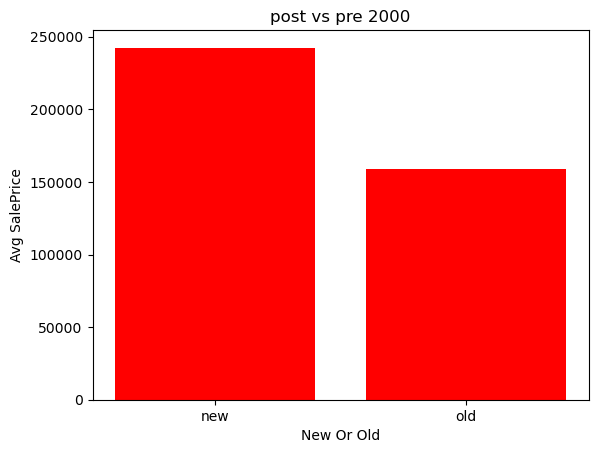

In [22]:
plt.bar(post_2000.index,post_2000.values,color='red')
plt.xlabel('New Or Old')
plt.ylabel('Avg SalePrice')
plt.title('post vs pre 2000')
plt.show()

### The House price Post-2000(New) are Higher than the old Houses 

### So, Based on this it is easy to understand that New Houses has higher Average SalePrice then the Old Houses in Market

####

#### What are the top factors influencing price (e.g., size, quality, location)?

In [61]:
cols=df[['SalePrice','GrLivArea','OverallQual','OverallCond','TotalBsmtSF','YearBuilt']]
cols

,SalePrice,GrLivArea,OverallQual,OverallCond,TotalBsmtSF,YearBuilt
0,208500,1710,7,5,856,2003
1,181500,1262,6,8,1262,1976
2,223500,1786,7,5,920,2001
3,140000,1717,7,5,756,1915
4,250000,2198,8,5,1145,2000
...,...,...,...,...,...,...
1455,175000,1647,6,5,953,1999
1456,210000,2073,6,6,1542,1978
1457,266500,2340,7,9,1152,1941
1458,142125,1078,5,6,1078,1950


In [62]:
cor=cols.corr()
cor

,SalePrice,GrLivArea,OverallQual,OverallCond,TotalBsmtSF,YearBuilt
SalePrice,1.000000,0.708624,0.790982,-0.077856,0.613581,0.522897
GrLivArea,0.708624,1.000000,0.593007,-0.079686,0.454868,0.199010
OverallQual,0.790982,0.593007,1.000000,-0.091932,0.537808,0.572323
OverallCond,-0.077856,-0.079686,-0.091932,1.000000,-0.171098,-0.375983
TotalBsmtSF,0.613581,0.454868,0.537808,-0.171098,1.000000,0.391452
YearBuilt,0.522897,0.199010,0.572323,-0.375983,0.391452,1.000000


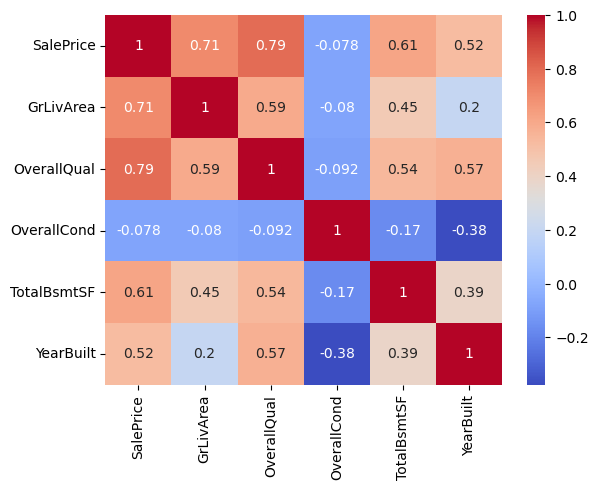

In [67]:
sns.heatmap(cor,annot=True, cmap='coolwarm')
plt.show()

### OverallQual and GrLivArea Columns are the top factors influencing SalePrice , which has a posivite Relationship
### Columns such as TotalBsmtSF and YearBuilt are has modrate influencing
### OverallCond Column has a negative relationship with SalesPrice
### Among all features, quality appears to have a stronger impact than size, indicating buyers prioritize construction quality over just space.

####

## 2. Growth & Distribution Analysis
### What are the yearly construction trends?

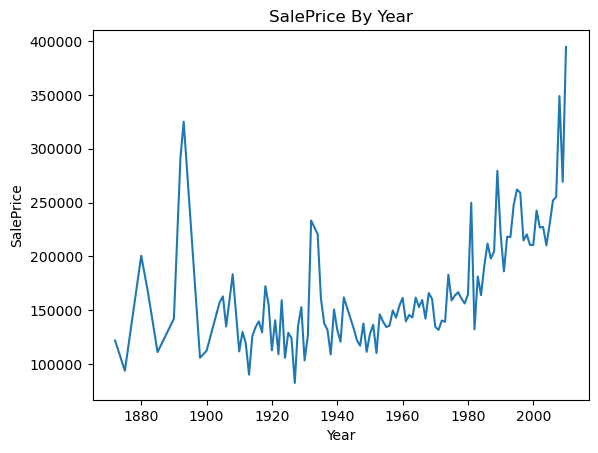

In [71]:
plt.plot(df.groupby('YearBuilt')['SalePrice'].mean())
plt.xlabel('Year')
plt.ylabel('SalePrice')
plt.title('SalePrice By Year')
plt.show()

### The trend shows that housing prices remained relatively volatile and stagnant between 1880 and 1940, with no consistent upward movement.

### From 1940 to 2000, prices exhibit a gradual upward trend with periodic fluctuations, indicating steady but moderate growth in the housing market.

### After 2000, there is a sharp and consistent increase in prices, suggesting a strong surge in housing demand and market value in recent years.

###

### Which year had the highest number of houses built?

In [85]:
built_count=df.groupby('YearBuilt')['Id'].count().idxmax()
built_count

np.int64(2006)

### The year 2006 had the highest number of houses built in the dataset, indicating a peak in construction activity during that period.

####

### Are we seeing a shift toward newer constructions?

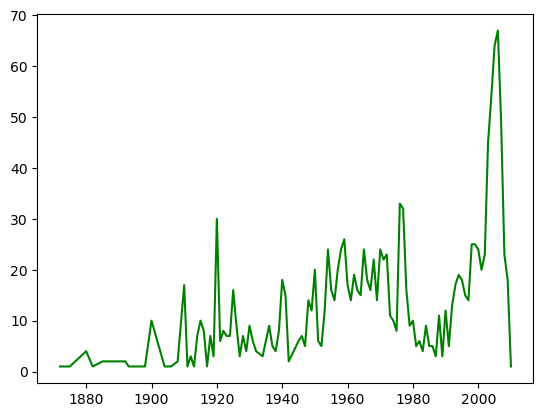

In [95]:
plt.plot(df.groupby('YearBuilt')['Id'].count(),color='green')
plt.show()

### The data shows relatively low and inconsistent construction activity before 1950, followed by gradual growth, and then a sharp surge in housing construction in the early 2000s 

#####

### 3. Neighborhood Insights
#### Which neighborhoods have the highest average prices?

In [14]:
avg_price=df.groupby('Neighborhood')['SalePrice'].mean().round(2).sort_values(ascending = False)
avg_price

Neighborhood
NoRidge    335295.32
NridgHt    316270.62
StoneBr    310499.00
Timber     242247.45
Veenker    238772.73
Somerst    225379.84
ClearCr    212565.43
Crawfor    210624.73
CollgCr    197965.77
Blmngtn    194870.88
Gilbert    192854.51
NWAmes     189050.07
SawyerW    186555.80
Mitchel    156270.12
NAmes      145847.08
NPkVill    142694.44
SWISU      142591.36
Blueste    137500.00
Sawyer     136793.14
OldTown    128225.30
Edwards    128219.70
BrkSide    124834.05
BrDale     104493.75
IDOTRR     100123.78
MeadowV     98576.47
Name: SalePrice, dtype: float64

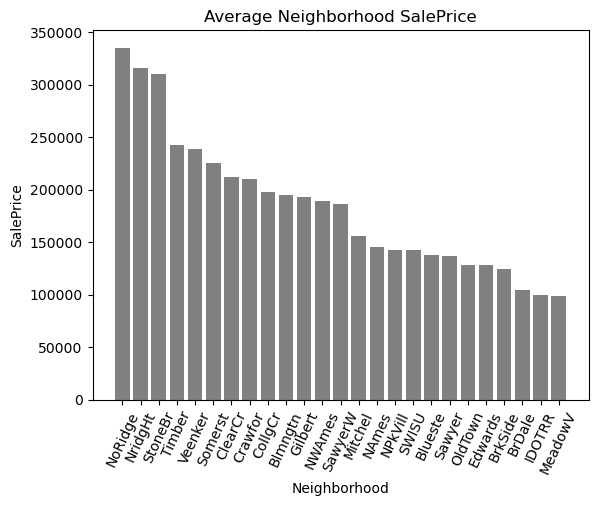

In [15]:
plt.bar(avg_price.index,avg_price.values,color='grey')
plt.xticks(rotation=65)
plt.xlabel("Neighborhood")
plt.ylabel('SalePrice')
plt.title("Average Neighborhood SalePrice")
plt.show()

### “NoRidge has the highest average sale price (~335K), followed by NridgHt and StoneBr.”
### The Neighborhood with the least average SalePrice is MeadowV with the 98576.47 average SalePrice
### The difference Between the most and least Average SalePrice is 236718.85

####

### Identify neighborhoods where:
#### Average price > overall average
#### BUT number of houses < average

In [3]:
overall_avg = df['SalePrice'].mean()
overall_avg

np.float64(180921.19589041095)

In [12]:
house_count = df.groupby('Neighborhood').size()
overall_count=house_count.mean()
overall_count

np.float64(58.4)

In [8]:
neigh_stats = df.groupby('Neighborhood').agg({
    'SalePrice': 'mean',   
}).rename(columns={'SalePrice': 'avg_price'})

neigh_stats['house_count'] = house_count

neigh_stats

,avg_price,house_count
Neighborhood,,
Blmngtn,194870.882353,17
Blueste,137500.000000,2
BrDale,104493.750000,16
BrkSide,124834.051724,58
ClearCr,212565.428571,28
CollgCr,197965.773333,150
Crawfor,210624.725490,51
Edwards,128219.700000,100
Gilbert,192854.506329,79


In [10]:
result = neigh_stats[
    (neigh_stats['avg_price'] > overall_avg) &
    (neigh_stats['house_count'] < overall_count)
]

result

,avg_price,house_count
Neighborhood,,
Blmngtn,194870.882353,17
ClearCr,212565.428571,28
Crawfor,210624.725490,51
NoRidge,335295.317073,41
StoneBr,310499.000000,25
Timber,242247.447368,38
Veenker,238772.727273,11


### Which neighborhoods have premium pricing per sqft?

In [4]:
df['Price per Sqft'] = df['SalePrice'] / df['GrLivArea']

In [16]:
Premium=df.groupby('Neighborhood')['Price per Sqft'].mean().sort_values(ascending=False).head(5)
Premium

Neighborhood
StoneBr    165.402275
NridgHt    164.578057
Veenker    154.980914
Somerst    141.335966
Timber     139.766483
Name: Price per Sqft, dtype: float64

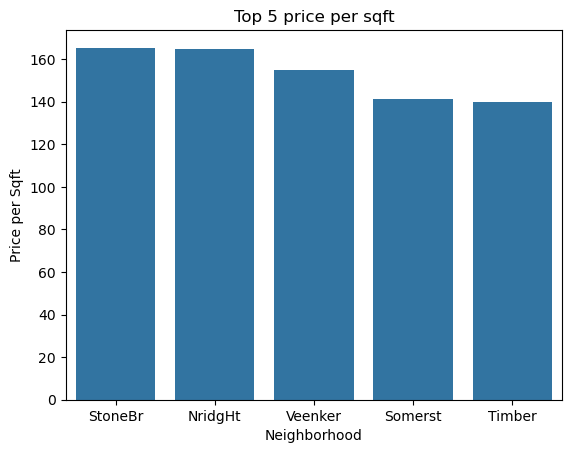

In [22]:
sns.barplot(data=Premium)
plt.title('Top 5 price per sqft')
plt.show()

### A comparison of average price per square foot across neighborhoods reveals that StoneBr and NridgHt lead significantly, followed by Veenker, Somerst, and Timber. These neighborhoods command premium pricing, indicating strong demand, better location advantages, or higher-quality housing, as buyers are willing to pay more per unit area.

#####

### 4. Pricing Efficiency
#### Create a price per sqft metric

In [5]:
df['Price per Sqft']

0       121.929825
1       143.819334
2       125.139978
3        81.537566
4       113.739763
           ...    
1455    106.253795
1456    101.302460
1457    113.888889
1458    131.841373
1459    117.436306
Name: Price per Sqft, Length: 1460, dtype: float64

### A new feature, price per square foot, was created by dividing the sale price by the above-ground living area (GrLivArea). This metric standardizes property prices by size, enabling fair comparison across homes and helping identify premium properties and high-value neighborhoods.

### Identify:
    Top 5 most expensive houses per sqft
    Any unusual outliers (extremely high values)

In [30]:
top_5=df['Price per Sqft'].sort_values(ascending = False).head()
top_5

688     276.250881
898     258.738156
1181    237.590799
440     231.057452
178     224.636079
Name: Price per Sqft, dtype: float64

##### Box Plot

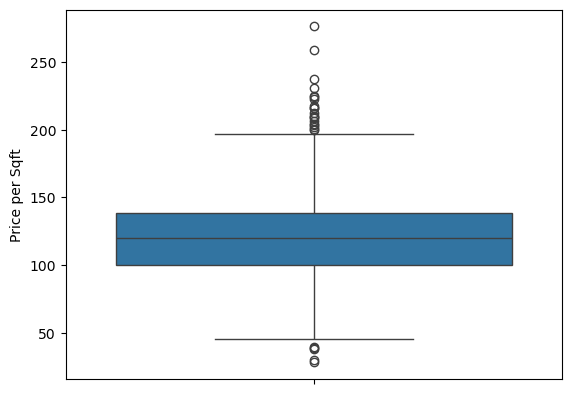

In [39]:
sns.boxplot(data=df,y=df['Price per Sqft'])
plt.show()

##### IQR

In [8]:
Q1 = df['Price per Sqft'].quantile(0.25).round(2)
Q3 = df['Price per Sqft'].quantile(0.75).round(2)

print('25th percentile:',Q1,'75th percentile:',Q3)

25th percentile: 99.82 75th percentile: 138.7


In [10]:
IQR = Q3-Q1
IQR.round(2)

np.float64(38.88)

In [11]:
lower = Q1-1.5*IQR
upper = Q1+1.5*IQR

In [12]:
lower,upper

(np.float64(41.5), np.float64(158.14))

##### Z_Score

In [15]:
df['z_score'] = (df['Price per Sqft'] - df["Price per Sqft"].mean()) / df['Price per Sqft'].std()

In [25]:
df[['Price per Sqft','z_score']].sort_values(by='z_score',ascending = False).head(5)

,Price per Sqft,z_score
688,276.250881,4.959307
898,258.738156,4.401418
1181,237.590799,3.727744
440,231.057452,3.519617
178,224.636079,3.315056


### Outliers were identified using multiple techniques including Z-score, IQR, and boxplot visualization. Among these, the IQR method was chosen as the most reliable because the dataset is skewed, which is common in real estate pricing. The IQR method is robust to extreme values and effectively identifies unusually high price per square foot values.

#####

### 5. Outlier & Data Quality Check
    Remove extreme outliers (above 99th percentile)
    Compare insights before vs after cleaning
    Do conclusions change?

In [40]:
df_1=df[df["Price per Sqft"] < df["Price per Sqft"].quantile(0.99).round(2)]
df_1

,Id,Neighborhood,HouseStyle,OverallQual,OverallCond,YearBuilt,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,MoSold,YrSold,SalePrice,Price per Sqft,z_score
0,1,CollgCr,2Story,7,5,2003,856,856,854,1710,2,2008,208500,121.929825,0.043227
1,2,Veenker,1Story,6,8,1976,1262,1262,0,1262,5,2007,181500,143.819334,0.740543
2,3,CollgCr,2Story,7,5,2001,920,920,866,1786,9,2008,223500,125.139978,0.145490
3,4,Crawfor,2Story,7,5,1915,756,961,756,1717,2,2006,140000,81.537566,-1.243516
4,5,NoRidge,2Story,8,5,2000,1145,1145,1053,2198,12,2008,250000,113.739763,-0.217677
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,Gilbert,2Story,6,5,1999,953,953,694,1647,8,2007,175000,106.253795,-0.456151
1456,1457,NWAmes,1Story,6,6,1978,1542,2073,0,2073,2,2010,210000,101.302460,-0.613882
1457,1458,Crawfor,2Story,7,9,1941,1152,1188,1152,2340,5,2010,266500,113.888889,-0.212926
1458,1459,NAmes,1Story,5,6,1950,1078,1078,0,1078,4,2010,142125,131.841373,0.358971


<Axes: xlabel='YearBuilt', ylabel='SalePrice'>

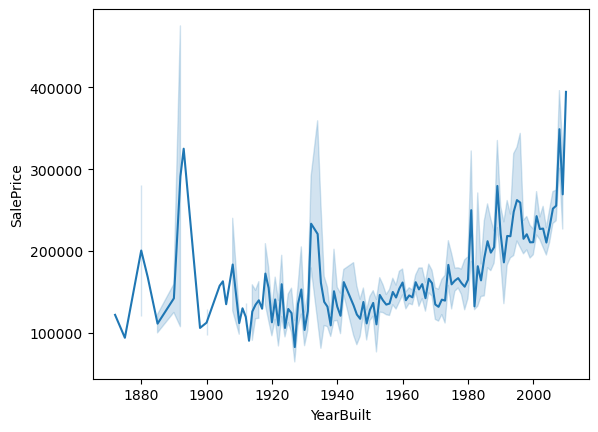

In [57]:
sns.lineplot(data=df,y=df['SalePrice'],x=df['YearBuilt'])

<Axes: xlabel='YearBuilt', ylabel='SalePrice'>

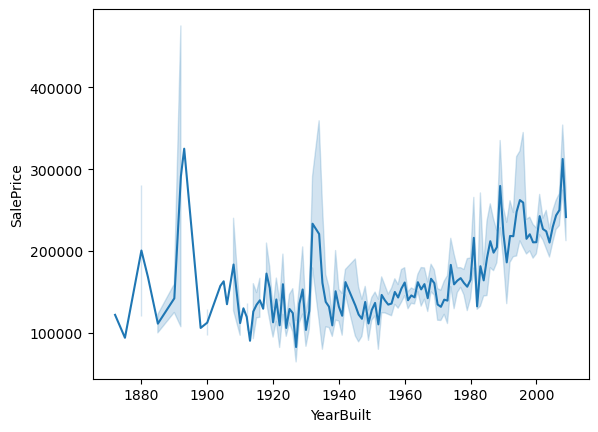

In [58]:
sns.lineplot(data=df_1,y=df_1['SalePrice'],x=df_1['YearBuilt'])

### Extreme outliers above the 99th percentile were removed to improve data quality. Before cleaning, the relationship between YearBuilt and SalePrice showed significant fluctuations due to a few unusually high-priced properties. After removing these outliers, the trend became smoother and revealed a clearer positive relationship, indicating that newer houses tend to have higher sale prices. While the overall conclusion remained the same, the cleaned data provided a more reliable and interpretable pattern.

### 6. Deep Dive Analysis
    Correlation between:
        GrLivArea and SalePrice
        Only for OverallQual > 5
    What does this tell us about premium housing segments?

In [59]:
overall=df[df['OverallQual'] > 5]
overall

,Id,Neighborhood,HouseStyle,OverallQual,OverallCond,YearBuilt,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,MoSold,YrSold,SalePrice,Price per Sqft,z_score
0,1,CollgCr,2Story,7,5,2003,856,856,854,1710,2,2008,208500,121.929825,0.043227
1,2,Veenker,1Story,6,8,1976,1262,1262,0,1262,5,2007,181500,143.819334,0.740543
2,3,CollgCr,2Story,7,5,2001,920,920,866,1786,9,2008,223500,125.139978,0.145490
3,4,Crawfor,2Story,7,5,1915,756,961,756,1717,2,2006,140000,81.537566,-1.243516
4,5,NoRidge,2Story,8,5,2000,1145,1145,1053,2198,12,2008,250000,113.739763,-0.217677
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1451,1452,Somerst,1Story,8,5,2008,1573,1578,0,1578,5,2009,287090,181.932826,1.954694
1454,1455,Somerst,1Story,7,5,2004,1221,1221,0,1221,10,2009,185000,151.515152,0.985703
1455,1456,Gilbert,2Story,6,5,1999,953,953,694,1647,8,2007,175000,106.253795,-0.456151
1456,1457,NWAmes,1Story,6,6,1978,1542,2073,0,2073,2,2010,210000,101.302460,-0.613882


In [61]:
df['GrLivArea'].corr(df['SalePrice'])

np.float64(0.7086244776126522)

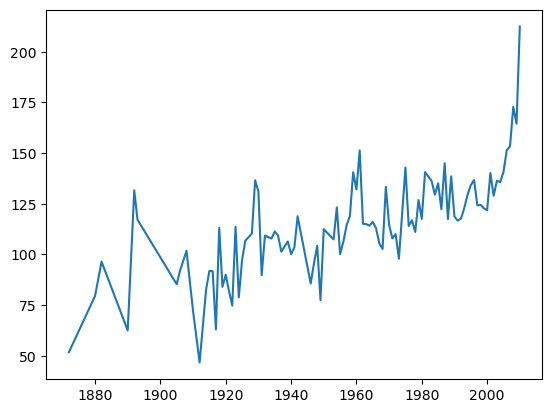

In [78]:
grp=overall.groupby('YearBuilt')['Price per Sqft'].mean()

plt.plot(grp.index,grp.values)
plt.show()

### The analysis of high-quality homes (OverallQual > 5) shows a strong positive correlation (0.70) between living area and sale price, indicating that property size plays a significant role in determining price within the premium segment. Additionally, the upward trend in price per square foot over time suggests that newer homes command higher value per unit area. This reflects changing market preferences, where buyers are willing to pay a premium for modern, high-quality housing.